In [1]:
import numpy as np
import matplotlib.pyplot as plt

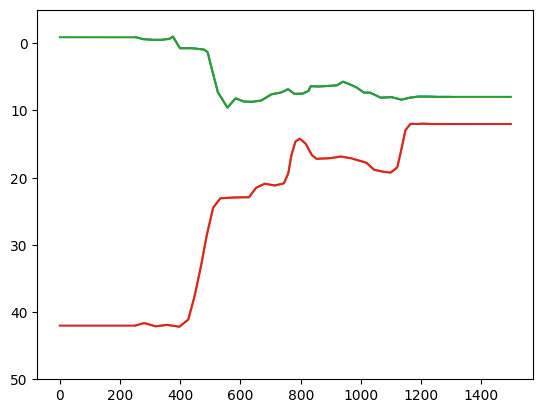

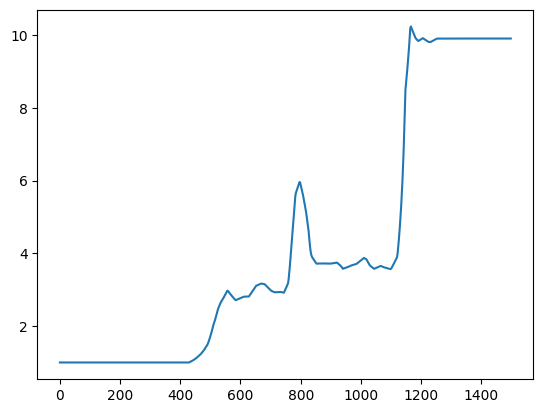

In [2]:
xb,yb = np.loadtxt("https://raw.githubusercontent.com/victorsacek/CursoPetrobras/master/SB02_Evain_basement.txt"
          ,unpack=True)

xm,ym = np.loadtxt("https://raw.githubusercontent.com/victorsacek/CursoPetrobras/master/SB02_Evain_moho.txt"
          ,unpack=True)

xb += 500.0
xm += 500.0

xb *= 1000.0
xm *= 1000.0

plt.plot(xb/1000,yb)
plt.plot(xm/1000,ym)
plt.ylim(50,-5)

dx = 2000.0 # Espaçamento vertical ou horizontal
x = np.arange(0.0, 1500.0E3,dx)

ybi = np.interp(x,xb,yb)
ymi = np.interp(x,xm,ym)

plt.plot(x/1000,ybi)
plt.plot(x/1000,ymi)

plt.figure()

beta = 40.0/(ymi-ybi)
beta[beta<1.0] = 1.0

plt.plot(x/1000,beta)






In [16]:

a = 125_000.0 # Espessura da litosfera
T1 = 1300.0 # Temperatura da base da litosfera

x = np.arange(0.0, 1500.0E3,dx)
z = np.arange(0.0,a,dx)

X,Z = np.meshgrid(x,z)


T = Z*T1*beta/a
T[T>T1]=T1

T0 = np.copy(T)
Tsoma0 = np.sum(T,axis=0)

t = 0.0
dt = 1000.0 # Passo de tempo em anos
kappa = 1.0E-6 # m2/s (difusividade térmica)
seg_por_ano = 365.0*24.0*60.0*60.0

fac = kappa*dt*seg_por_ano/dx**2
tprint=0.0

alpha = 3.28E-5 # 1/K
rhom = 3300.0
rhow = 1000.0

ww=[]

while t<81.0E6:
  T[1:-1,1:-1] += fac*(T[:-2,1:-1]+T[2:,1:-1]+
                       T[1:-1,:-2]+T[1:-1,2:]-
                       4*T[1:-1,1:-1])

  T[:,-1] = T[:,-2]
  if t>=tprint:
    Tsoma = np.sum(T,axis=0)
    #plt.figure(figsize=(10,1))
    #plt.title("%.2f Myr"%(t/1.0E6))
    w = (Tsoma-Tsoma0)*dx*alpha*rhom/(rhom-rhow)
    ww = np.append(ww,w)
    #plt.plot(x/1000,w/1000)
    #plt.ylim(-3.5,0.5)
    #plt.grid()

    #plt.figure(figsize=(10,1))

    #plt.contourf(X/1000,Z/1000,T,100,cmap="magma")
    #plt.ylim(a/1000,0)
    tprint+=1.0E6

  t+=dt

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

#-----------------------

# Modelo inicial

#-----------------------

a = 125_000.0
T1 = 1300.0

x = np.arange(0.0,1500.e3,dx)
z = np.arange(0.0,a,dx)

X,Z = np.meshgrid(x,z)
T = Z*T1*beta/a
T[T>T1] = T1

T0 = T.copy()

Tsoma0 = np.sum(T,axis=0)

dt = 1000.0
kappa = 1e-6
seg_por_ano = 365*24*60*60
fac = kappa*dt*seg_por_ano/dx**2
alpha = 3.28e-5
rhom = 3300.
rhow = 1000.


#-----------------------
# Parâmetros da animação
#-----------------------

tempo_por_frame = 1.0e6       # 1 Myr por quadro
passos = int(tempo_por_frame/dt)

fig,(ax1,ax2)=plt.subplots(
    2,1,
    figsize=(10,6),
    constrained_layout=True
)

#-----------------------
# Função chamada a cada frame
#-----------------------

def update(frame):
    global T
    # avança o modelo
    for _ in range(passos):
        T[1:-1,1:-1] += fac*(
            T[:-2,1:-1] +
            T[2:,1:-1] +
            T[1:-1,:-2] +
            T[1:-1,2:] -
            4*T[1:-1,1:-1]
        )
        T[:,-1]=T[:,-2]

    # subsidência
    Tsoma=np.sum(T,axis=0)

    w=(Tsoma-Tsoma0)*dx*alpha*rhom/(rhom-rhow)
    # limpa os eixos

    ax1.clear()
    ax2.clear()

    # perfil de subsidência
    ax1.plot(x/1000,w/1000,lw=2)
    ax1.grid(True)
    ax1.set_ylim(-3.5,0.5)
    ax1.set_ylabel("Subs. (km)")
    ax1.set_title(f"{(frame+1):.0f} Myr")

    # temperatura
    cf=ax2.contourf(
        X/1000,
        Z/1000,
        T,
        levels=100,
        cmap="magma"
    )

    ax2.set_ylim(a/1000,0)
    ax2.set_xlabel("Distância (km)")
    ax2.set_ylabel("Profundidade (km)")

#-----------------------
# Animação
#-----------------------

ani = FuncAnimation(
    fig,
    update,
    frames=81,
    interval=100,
    repeat=False
)

HTML(ani.to_jshtml())

Output hidden; open in https://colab.research.google.com to view.

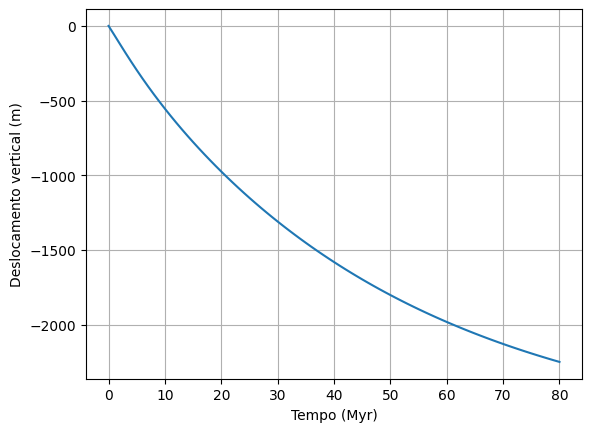

In [33]:
w_history = np.reshape(ww,(np.size(ww)//np.size(x),np.size(x)))

np.shape(w_history)

t_history = np.arange(0,81,1.)

plt.plot(t_history,w_history[:,x==1000.0E3])

plt.xlabel("Tempo (Myr)")
plt.ylabel("Deslocamento vertical (m)")
plt.grid()

In [12]:
ww

[]